In [5]:
import random
import time

import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

In [6]:
# settings
env_id  = "CartPole-v1"

# number of environments to run in parallel
num_envs = 1

# total number of timesteps for training over multiple episodes
total_timesteps = 100_000

# adam learning rate
learning_rate = 1e-3

# discount factor
gamma = 0.99

# epsilon value for epsilon-greedy (prob of choosing a random action)
eps = 0.1

# optional: set seed for reproducibility
# seed = 123
seed = None

video_path = "qlearning_cartpole_videos"

In [7]:
def make_env(env_id, capture_video, seed=None):
  if capture_video:
    env = gym.make(env_id, render_mode="rgb_array")
    env = gym.wrappers.RecordVideo(env, video_path,
            episode_trigger=lambda episode: True)
  else:
    env = gym.make(env_id)
  env = gym.wrappers.RecordEpisodeStatistics(env)

  if seed is not None:
    env.action_space.seed(seed)
  return env

In [8]:
class QNetwork(nn.Module):
  def __init__(self, envs, n_hidden=128):
    super().__init__()
    self.network = nn.Sequential(
      nn.Linear(np.array(envs.single_observation_space.shape).prod(), n_hidden),
      nn.ReLU(),
      nn.Linear(n_hidden, envs.single_action_space.n)
    )

  def forward(self, x):
    return self.network(x)

In [9]:
# optional: set seeds for reproducibility
# random.seed(seed)
# np.random.seed(seed)
# torch.manual_seed(seed)
# torch.backends.cudnn.deterministic = True

In [10]:
# make environments
envs = gym.vector.SyncVectorEnv([
  lambda: make_env(
      env_id,
      capture_video=False,
      seed=seed if seed is None else seed + i)
  for i in range(num_envs)
])

In [11]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else
    "mps" if torch.backends.mps.is_available() else
    "cpu"
)

In [12]:
# make neural networks
q_network = QNetwork(envs).to(device)
optimizer = optim.Adam(q_network.parameters(), lr=learning_rate)

In [13]:
def np2torch(a):
  return torch.as_tensor(a, dtype=torch.float32, device=device)

In [14]:
# training loop

episode_returns = []
losses = []

start_time = time.time()
obs, _ = envs.reset(seed=seed)
autoreset = np.zeros(num_envs, dtype=bool)

for global_step in range(total_timesteps):

  # select action based on epsilon-greedy strategy
  if random.random() < eps:
    actions = np.array(
        [envs.single_action_space.sample() for _ in range(num_envs)])
  else:
    q_values = q_network(np2torch(obs))
    actions = torch.argmax(q_values, dim=1).cpu().numpy()

  # take a step in the environment
  next_obs, rewards, dones, truncateds, infos = envs.step(actions)

  # record returns for plotting
  for i, (done, truncated) in enumerate(zip(dones, truncateds)):
    if done or truncated:
      ret = infos['episode']['r'][i]
      episode_returns.append(ret)
      print(f"global_step={global_step}, episode={len(episode_returns)}, episode_return={ret}")

  # training
  # use only envs that haven't been autoreset
  mask = np.logical_not(autoreset)
  obs_ = obs[mask]
  actions_ = actions[mask]
  rewards_ = rewards[mask]
  next_obs_ = next_obs[mask]
  dones_ = dones[mask]
  if np.any(mask):
    with torch.no_grad():
      q_next, _ = q_network(np2torch(next_obs_)).max(dim=1)
      td_target = np2torch(rewards_) + gamma * (1 - np2torch(dones_)) * q_next
    pred = q_network(np2torch(obs_)).gather(
        1, torch.from_numpy(actions_.reshape(-1, 1)).to(device))

    loss = F.mse_loss(td_target.squeeze(), pred.squeeze())
    losses.append(loss.detach().cpu().numpy())

    # optimize
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

  # don't forget
  obs = next_obs

  # update autoreset
  autoreset = np.logical_or(dones, truncateds)

  if global_step % 1000 == 0:
    print("steps per second:", int(global_step / (time.time() - start_time)))

  # let's break if the last 10 episodes had max reward
  if len(episode_returns) > 10 and np.all(np.equal(episode_returns[-10:], 500)):
    print("max reward achieved")
    break

steps per second: 0
global_step=12, episode=1, episode_return=13.0
global_step=27, episode=2, episode_return=14.0
global_step=39, episode=3, episode_return=11.0
global_step=51, episode=4, episode_return=11.0
global_step=61, episode=5, episode_return=9.0
global_step=71, episode=6, episode_return=9.0
global_step=83, episode=7, episode_return=11.0
global_step=97, episode=8, episode_return=13.0
global_step=109, episode=9, episode_return=11.0
global_step=118, episode=10, episode_return=8.0
global_step=129, episode=11, episode_return=10.0
global_step=141, episode=12, episode_return=11.0
global_step=159, episode=13, episode_return=17.0
global_step=171, episode=14, episode_return=11.0
global_step=182, episode=15, episode_return=10.0
global_step=196, episode=16, episode_return=13.0
global_step=206, episode=17, episode_return=9.0
global_step=217, episode=18, episode_return=10.0
global_step=230, episode=19, episode_return=12.0
global_step=240, episode=20, episode_return=9.0
global_step=249, episo

In [15]:
# close env
envs.close()

In [16]:
def smooth(x, a=0.1):
    y = [x[0]]
    for xi in x[1:]:
        yi = a * xi + (1 - a) * y[-1]
        y.append(yi)
    return y

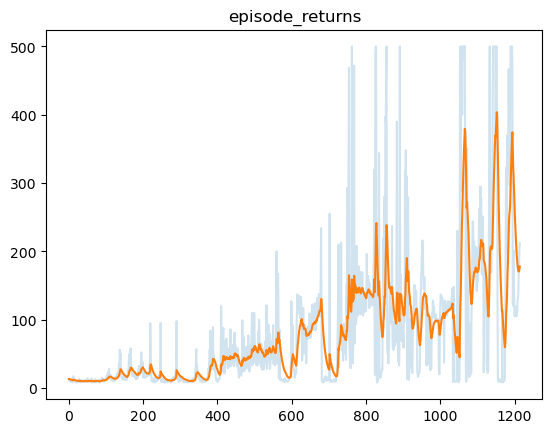

In [17]:
plt.plot(episode_returns, alpha=0.2)
plt.plot(smooth(episode_returns))
plt.title("episode_returns");
plt.show();

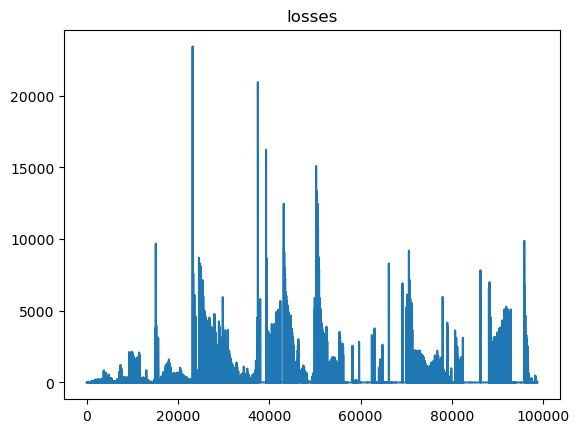

In [18]:
plt.plot(losses)
plt.title("losses");
plt.show();

In [19]:
# save model
model_path = "q_network.pth"
torch.save(q_network.state_dict(), model_path)

In [20]:
# load model for eval
envs_eval = gym.vector.SyncVectorEnv([lambda: make_env(env_id, True)])
model = QNetwork(envs_eval).to(device)
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()

QNetwork(
  (network): Sequential(
    (0): Linear(in_features=4, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=2, bias=True)
  )
)

In [21]:
# evaluate the model
n_episodes_eval = 10
eval_returns = np.zeros(n_episodes_eval)
obs, _ = envs_eval.reset()
for i in range(n_episodes_eval):
  episode_done = False
  while not episode_done:
    q_values = model(np2torch(obs))
    actions = torch.argmax(q_values, dim=1).cpu().numpy()
    obs, rewards, dones, truncateds, infos = envs_eval.step(actions)
    if dones[0] or truncateds[0]:
      G = infos['episode']['r'][0]
      print(f"episode={i}, return={G}")
      eval_returns[i] = G
      episode_done = True

# close env
envs_eval.close()

/opt/homebrew/Caskroom/miniconda/base/envs/rl/lib/python3.13/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


episode=0, return=141.0
episode=1, return=132.0
episode=2, return=141.0
episode=3, return=139.0
episode=4, return=135.0
episode=5, return=135.0
episode=6, return=132.0
episode=7, return=133.0
episode=8, return=132.0
episode=9, return=136.0


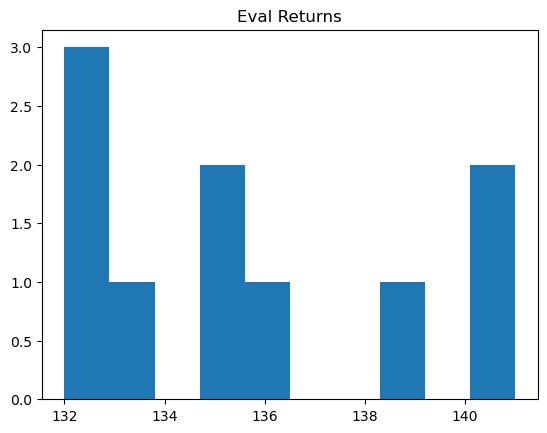

In [22]:
# plot the eval returns distribution
plt.hist(eval_returns)
plt.title("Eval Returns")
plt.show();

In [ ]:
# prompt: display video in colab notebook with filename "videos/rl-video-episode-0.mp4"

from IPython.display import HTML
from base64 import b64encode

mp4 = open(f'{video_path}/rl-video-episode-0.mp4','rb').read()
data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
HTML("""
<video width=400 controls>
      <source src="%s" type="video/mp4">
</video>
""" % data_url)

: 

![](https://deeplearningcourses.com/notebooks_v3_pxl?sc=tBcMwmqWvdC3-tOq-bEJpQ&n=Q+Learning)